<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Removing Duplicates**


Estimated time needed: **30** minutes


## Introduction


In this lab, you will focus on data wrangling, an important step in preparing data for analysis. Data wrangling involves cleaning and organizing data to make it suitable for analysis. One key task in this process is removing duplicate entries, which are repeated entries that can distort analysis and lead to inaccurate conclusions.  


## Objectives


In this lab you will perform the following:


1. Identify duplicate rows  in the dataset.
2. Use suitable techniques to remove duplicate rows and verify the removal.
3. Summarize how to handle missing values appropriately.
4. Use ConvertedCompYearly to normalize compensation data.
   


### Install the Required Libraries


In [1]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 127.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 154.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]


In [10]:
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 113.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 94.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 97.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [seaborn]


In [11]:
!pip install matplotlib

### Step 1: Import Required Libraries


In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

%matplotlib

Using matplotlib backend: module://matplotlib_inline.backend_inline

### Step 2: Load the Dataset into a DataFrame



load the dataset using pd.read_csv()


In [3]:
# Define the URL of the dataset
file_path ="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"

# Load the dataset into a DataFrame
df = pd.read_csv(file_path)

# Display the first few rows to ensure it loaded correctly
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

**Note: If you are working on a local Jupyter environment, you can use the URL directly in the <code>pandas.read_csv()</code>  function as shown below:**



In [ ]:
#df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv")

### Step 3: Identifying Duplicate Rows


**Task 1: Identify Duplicate Rows**
  1. Count the number of duplicate rows in the dataset.
  2. Display the first few duplicate rows to understand their structure.


In [4]:
## Write your code here
# 1. Count full-row duplicates (where every single column is identical)
full_duplicates_count = df.duplicated().sum()
print(f"Total full-row duplicate rows: {full_duplicates_count}")

# 2. Count primary key duplicates (where ResponseId appears more than once)
id_duplicates_count = df.duplicated(subset=["ResponseId"]).sum()
print(f"Total duplicate ResponseId records: {id_duplicates_count}")

# 3. Display the first few duplicate rows based on ResponseId to inspect their structure
print("\nFirst few duplicate records (showing both original and duplicate entries):")
duplicate_samples = df[df.duplicated(subset=["ResponseId"], keep=False)].sort_values("ResponseId")
display(duplicate_samples.head(6))

Total full-row duplicate rows: 10
Total duplicate ResponseId records: 10

First few duplicate records (showing both original and duplicate entries):

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65437,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65438,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
65439,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN


### Step 4: Removing Duplicate Rows


**Task 2: Remove Duplicates**
   1. Remove duplicate rows from the dataset using the drop_duplicates() function.
2. Verify the removal by counting the number of duplicate rows after removal .


In [6]:
# using drop duplicates on the whole data set as we verified that the duplicated rows are the same as 
# the rows with the same ResponseId
df_clean = df.drop_duplicates()
# verify the removal
duplicates_count = df_clean.duplicated(subset=['ResponseId']).sum()
print(f"Duplicate rows: {duplicates_count}")

Duplicate rows: 0

### Step 5: Handling Missing Values


**Task 3: Identify and Handle Missing Values**
   1. Identify missing values for all columns in the dataset.
   2. Choose a column with significant missing values (e.g., EdLevel) and impute with the most frequent value.


In [7]:
# Count missing values for each column
missing_per_column = df_clean.isnull().sum()

# Display only columns that actually have missing values (sorted descending)
missing_per_column = missing_per_column[missing_per_column > 0].sort_values(ascending=False)
print(missing_per_column)

AINextMuch less integrated    64289
AINextLess integrated         63082
AINextNo change               52939
AINextMuch more integrated    51999
EmbeddedAdmired               48704
                              ...  
YearsCode                      5568
NEWSOSites                     5151
LearnCode                      4949
EdLevel                        4653
AISelect                       4530
Length: 109, dtype: int64

In [8]:
# Calculate percentage of missing values per column
missing_summary = pd.DataFrame({
    'Missing_Count': df_clean.isnull().sum(),
    'Missing_Percentage': (df_clean.isnull().sum() / len(df_clean)) * 100
})

# Filter to show columns with missing data, sorted by highest percentage
missing_summary = missing_summary[missing_summary['Missing_Count'] > 0].sort_values(by='Missing_Percentage', ascending=False)
display(missing_summary.head(15))

,Missing_Count,Missing_Percentage
AINextMuch less integrated,64289,98.245641
AINextLess integrated,63082,96.401119
AINextNo change,52939,80.900714
AINextMuch more integrated,51999,79.464217
EmbeddedAdmired,48704,74.428840
EmbeddedWantToWorkWith,47837,73.103901
EmbeddedHaveWorkedWith,43223,66.052845
ConvertedCompYearly,42002,64.186928
AIToolNot interested in Using,41023,62.690832
AINextMore integrated,41009,62.669438


As there are too many columns with missing data we will plot the top 25 ones.

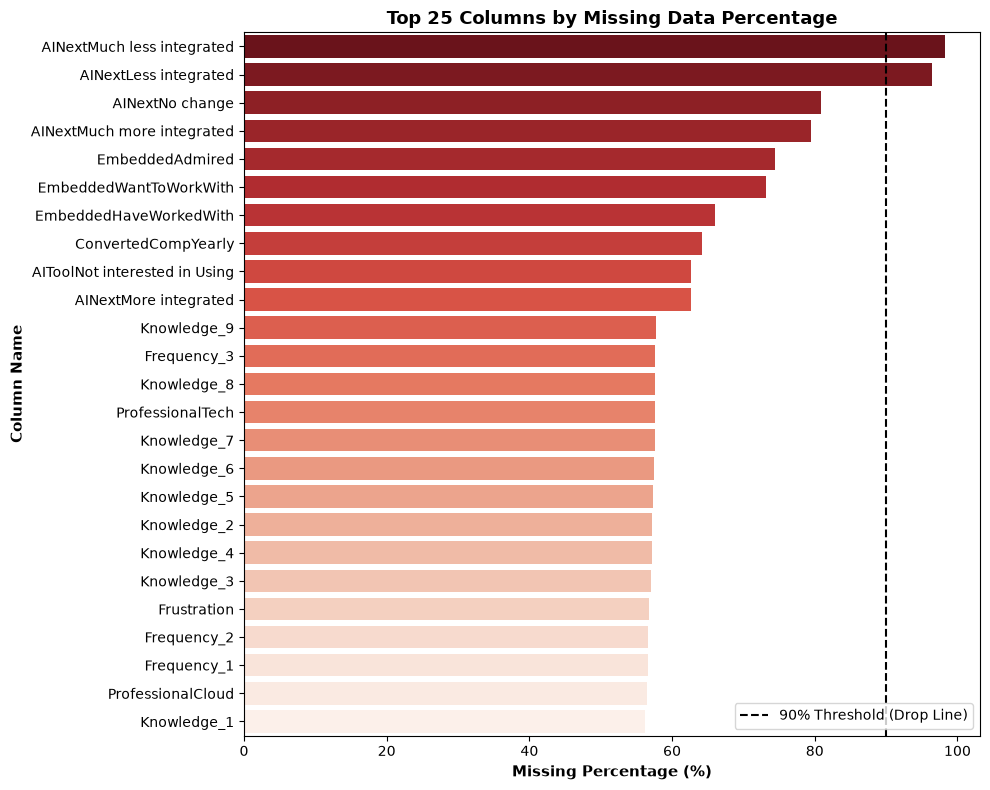

In [13]:
# Calculate missing percentage per column
missing_pct = (df_clean.isnull().sum() / len(df_clean)) * 100
missing_df = (
    missing_pct[missing_pct > 0]
    .reset_index(name="Missing_Pct")
    .rename(columns={"index": "Column"})
)
missing_df = missing_df.sort_values("Missing_Pct", ascending=False)

# Plot top 25 missing columns
plt.figure(figsize=(10, 8))
sns.barplot(
    data=missing_df.head(25),
    x="Missing_Pct",
    y="Column",
    hue="Column",
    legend=False,
    palette="Reds_r",
)

plt.axvline(
    x=90, color="black", linestyle="--", label="90% Threshold (Drop Line)"
)
plt.title(
    "Top 25 Columns by Missing Data Percentage", fontsize=13, fontweight="bold"
)
plt.xlabel("Missing Percentage (%)", fontsize=11, fontweight="bold")
plt.ylabel("Column Name", fontsize=11, fontweight="bold")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [14]:
# Identify columns with > 90% missing values
cols_to_drop = missing_pct[missing_pct > 90].index.tolist()
print(f"Dropping {len(cols_to_drop)} columns with > 90% missing data:")
print(cols_to_drop)

# Drop columns from DataFrame
df_clean.drop(columns=cols_to_drop, inplace=True)

Dropping 2 columns with > 90% missing data:
['AINextLess integrated', 'AINextMuch less integrated']

Collumns with more than 25% missing data are not suitable for most frequent value imputing as it will distort the data too much.
It's best to choose a column with moderate missingness in the interval 5%-25%.

In [16]:
# Filter for columns with missing values between 5% and 25%
sweet_spot_cols = missing_pct[(missing_pct >= 5) & (missing_pct <= 25)].sort_values(ascending=False)

print("Columns with 5% to 25% missing values:")
print(sweet_spot_cols)

Columns with 5% to 25% missing values:
LearnCodeOnline                  24.756636
DatabaseHaveWorkedWith           23.202470
NEWCollabToolsAdmired            22.504088
LanguageAdmired                  22.258050
YearsCodePro                     21.130247
NEWCollabToolsWantToWorkWith     20.401302
ToolsTechHaveWorkedWith          19.797668
OpSysProfessional use            19.047328
CodingActivities                 16.765744
RemoteWork                       16.246160
OfficeStackSyncHaveWorkedWith    15.116830
LanguageWantToWorkWith           14.800495
SurveyLength                     14.143375
SurveyEase                       14.057796
NEWCollabToolsHaveWorkedWith     11.988630
OpSysPersonal use                11.099225
Country                           9.943916
SOHow                             9.895014
SOComm                            9.587848
DevType                           9.156899
SOVisitFreq                       9.017834
SOAccount                         8.981157
LanguageHaveWor

Let's choose EdLevel as it is single select categorical value with low missingness and a dominant majority class.

In [22]:
df_clean['EdLevel'].value_counts()

EdLevel
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                          24942
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                       15557
Some college/university study without earning a degree                                 7651
Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)     5793
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                                         2970
Associate degree (A.A., A.S., etc.)                                                    1793
Primary/elementary school                                                              1146
Something else                                                                          932
Name: count, dtype: int64

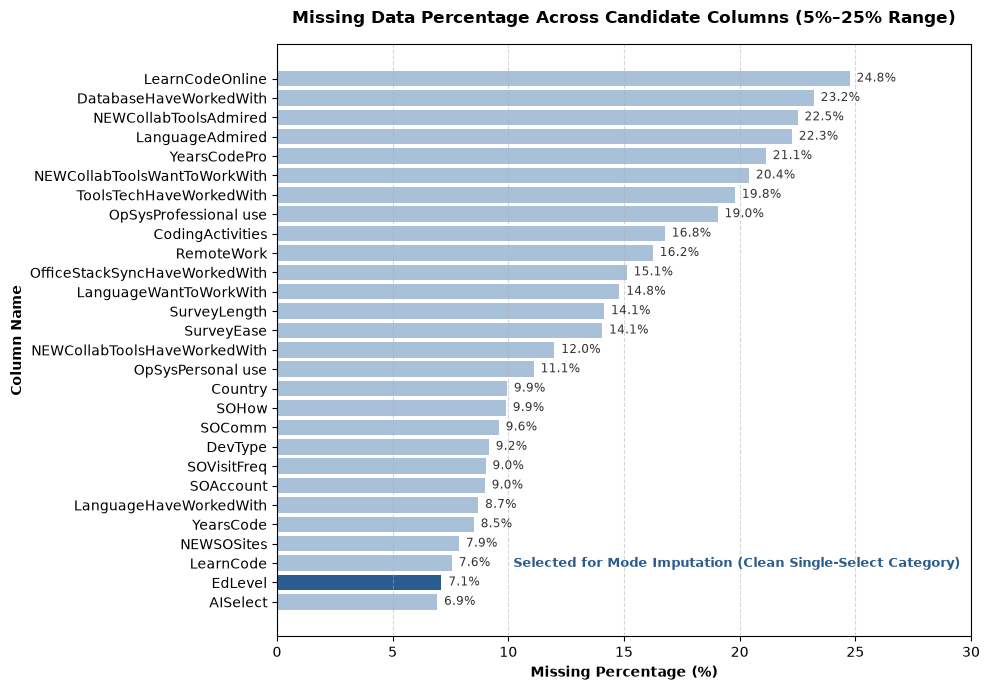

In [24]:
# Filter missing percentages to the 5%-25% sweet spot in a df
sweet_spot = (
    missing_pct[(missing_pct >= 5) & (missing_pct <= 25)]
    .reset_index()
    .rename(columns={"index": "Column", 0: "Missing_Pct"})
    .sort_values("Missing_Pct", ascending=True)
)

# Highlight EdLevel as the chosen column
colors = [
    "#2b5c8f" if col == "EdLevel" else "#a8c0d8" for col in sweet_spot["Column"]
]

# Plot Horizontal Bar Chart
plt.figure(figsize=(10, 7))
bars = plt.barh(
    sweet_spot["Column"],
    sweet_spot["Missing_Pct"],
    color=colors,
    edgecolor="none",
)

# Annotate exact percentage on each bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center",
        ha="left",
        fontsize=8.5,
        color="#333333",
    )

plt.title(
    "Missing Data Percentage Across Candidate Columns (5%–25% Range)",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Missing Percentage (%)", fontsize=10, fontweight="bold")
plt.ylabel("Column Name", fontsize=10, fontweight="bold")
plt.xlim(0, 30)
plt.grid(axis="x", linestyle="--", alpha=0.5)

# Highlight callout for EdLevel
plt.text(
    10,
    sweet_spot[sweet_spot["Column"] == "EdLevel"].index[0] - 0.2,
    " Selected for Mode Imputation (Clean Single-Select Category)",
    fontsize=9,
    fontweight="bold",
    color="#2b5c8f",
)

plt.tight_layout()
plt.show()

In [23]:
target_col = "EdLevel"

# Find the most frequent value (Mode)
mode_value = df_clean[target_col].mode()[0]
missing_before = df_clean[target_col].isnull().sum()
pct_before = (missing_before / len(df_clean)) * 100

print(f"--- Pre-Imputation Analysis for '{target_col}' ---")
print(f"Missing count: {missing_before:,} ({pct_before:.2f}%)")
print(f"Most Frequent Value (Mode): '{mode_value}'")

# Impute missing values with the mode
df_clean[target_col] = df_clean[target_col].fillna(mode_value)

# Verify post-imputation state
missing_after = df_clean[target_col].isnull().sum()
print(f"\n--- Post-Imputation Verification ---")
print(f"Remaining missing values in '{target_col}': {missing_after}")

--- Pre-Imputation Analysis for 'EdLevel' ---
Missing count: 4,653 (7.11%)
Most Frequent Value (Mode): 'Bachelor’s degree (B.A., B.S., B.Eng., etc.)'

--- Post-Imputation Verification ---
Remaining missing values in 'EdLevel': 0

### Step 6: Normalizing Compensation Data


**Task 4: Normalize Compensation Data Using ConvertedCompYearly**
   1. Use the ConvertedCompYearly column for compensation analysis as the normalized annual compensation is already provided.
   2. Check for missing values in ConvertedCompYearly and handle them if necessary.


In [25]:
# check missing values in ConvertedCompYearly
missing_count = df_clean["ConvertedCompYearly"].isnull().sum()
missing_pct = (missing_count / len(df_clean)) * 100

print(f"--- ConvertedCompYearly Audit ---")
print(f"Missing Values: {missing_count:,} out of {len(df_clean):,} rows")
print(f"Missing Percentage: {missing_pct:.2f}%")

--- ConvertedCompYearly Audit ---
Missing Values: 42,002 out of 65,437 rows
Missing Percentage: 64.19%

Creating a subset for compensation analysis.

In [26]:
# Create a dedicated salary subset for compensation analysis
df_comp = df_clean.dropna(subset=["ConvertedCompYearly"]).copy()

print(
    f"\nCleaned salary dataset size: {len(df_comp):,} rows (removed {missing_count:,} missing records)"
)


Cleaned salary dataset size: 23,435 rows (removed 42,002 missing records)

In [27]:
# Summary statistics
summary_stats = df_comp["ConvertedCompYearly"].describe().apply(lambda x: f"${x:,.2f}")
print("\nConvertedCompYearly Summary Statistics:")
print(summary_stats)


ConvertedCompYearly Summary Statistics:
count        $23,435.00
mean         $86,155.29
std         $186,756.97
min               $1.00
25%          $32,712.00
50%          $65,000.00
75%         $107,971.50
max      $16,256,603.00
Name: ConvertedCompYearly, dtype: str

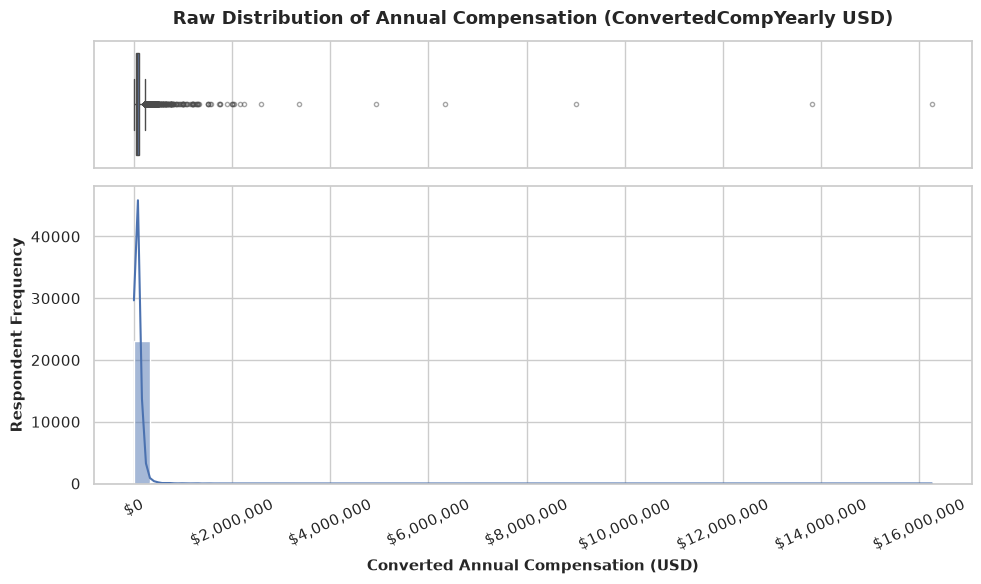

In [30]:
import matplotlib.ticker as ticker
sns.set_theme(style="whitegrid", font="sans-serif")

# Filter to non-null compensation records for plotting
comp_data = df_clean["ConvertedCompYearly"].dropna()

fig, (ax_box, ax_hist) = plt.subplots(
    2, 1, figsize=(10, 6), sharex=True, gridspec_kw={"height_ratios": [0.3, 0.7]}
)

# Box Plot (Top)
sns.boxplot(
    x=comp_data,
    ax=ax_box,
    color="#4c72b0",
    fliersize=3,
    flierprops=dict(marker="o", color="red", alpha=0.5),
)
ax_box.set(xlabel="")
ax_box.set_title(
    "Raw Distribution of Annual Compensation (ConvertedCompYearly USD)",
    fontsize=13,
    fontweight="bold",
    pad=12,
)

# Histogram + Density Curve (Bottom)
sns.histplot(x=comp_data, ax=ax_hist, bins=50, kde=True, color="#4c72b0")
ax_hist.set_xlabel(
    "Converted Annual Compensation (USD)", fontsize=11, fontweight="bold"
)
ax_hist.set_ylabel("Respondent Frequency", fontsize=11, fontweight="bold")

# Format X-axis with currency formatting
ax_hist.xaxis.set_major_formatter("${x:,.0f}")
plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

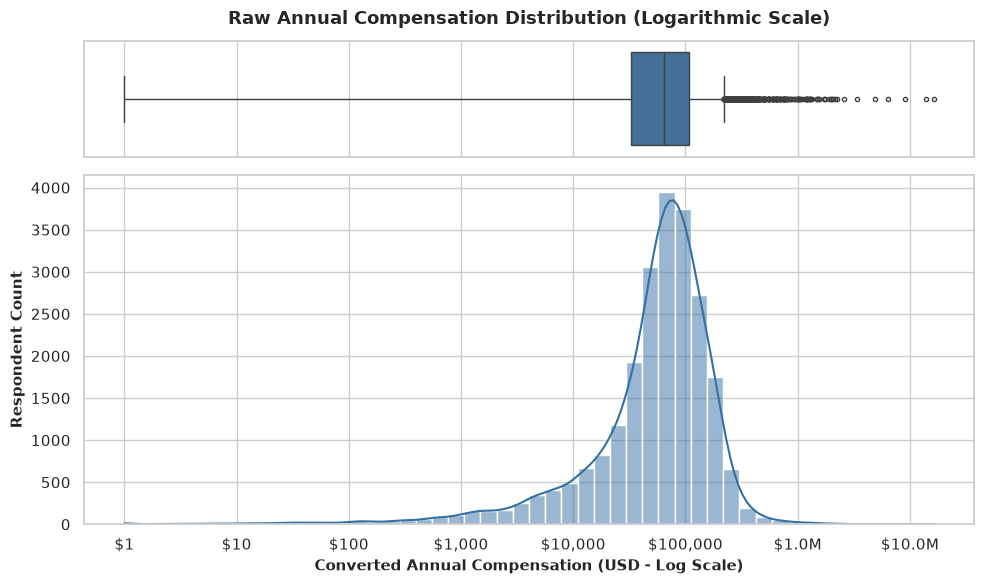

In [31]:
import matplotlib.ticker as ticker
sns.set_theme(style="whitegrid", font="sans-serif")

# Filter out non-null and positive values (log scale requires > 0)
comp_data = df_clean[df_clean["ConvertedCompYearly"] > 0][
    "ConvertedCompYearly"
].dropna()

fig, (ax_box, ax_hist) = plt.subplots(
    2, 1, figsize=(10, 6), sharex=True, gridspec_kw={"height_ratios": [0.25, 0.75]}
)

# Boxplot on Log Scale
sns.boxplot(x=comp_data, ax=ax_box, color="#3470a3", fliersize=3)
ax_box.set(xscale="log", xlabel="")
ax_box.set_title(
    "Raw Annual Compensation Distribution (Logarithmic Scale)",
    fontsize=13,
    fontweight="bold",
    pad=12,
)

# Histogram on Log Scale
sns.histplot(x=comp_data, ax=ax_hist, bins=50, kde=True, color="#3470a3")
ax_hist.set(xscale="log")
ax_hist.set_xlabel(
    "Converted Annual Compensation (USD - Log Scale)",
    fontsize=11,
    fontweight="bold",
)
ax_hist.set_ylabel("Respondent Count", fontsize=11, fontweight="bold")

# Clean currency formatting for Log X-Axis ticks ($1k, $10k, $100k, $1M)
formatter = ticker.FuncFormatter(
    lambda y, _: f"${y:,.0f}" if y < 1e6 else f"${y/1e6:,.1f}M"
)
ax_hist.xaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

### Key Insights & Outlier Diagnostic

1. **Extreme Right Skewness:**
   * The median annual compensation is **$65,000**, whereas the maximum value reaches **$16,256,603**.
   * The standard deviation (**$186,757**) is more than double the mean (**$86,155**), confirming that extreme upper outliers heavily pull the arithmetic average upward.

2. **Presence of Unrealistic Floor Values:**
   * Minimum reported compensation is **$1.00**, indicating non-salaried responses, volunteer roles, or test/incomplete submissions.

---

### Proposed Future Cleaning & Trimming Strategy

To prevent these extreme values from corrupting downstream statistical modeling, correlation analysis, and regression tasks, the following preprocessing pipeline is recommended for future modules:

1. **Missing Data Handling:** 
   * Exclude records where `ConvertedCompYearly` is `NaN` (~64% of total dataset) when running salary-specific benchmarking models, rather than imputing, to avoid synthetic wage bias.

2. **Interquartile Range (IQR) Trimming:**
   * Apply a standard $1.5 \times \text{IQR}$ filter:
     $$\text{Upper Threshold} = Q3 + (1.5 \times \text{IQR})$$
   * Establish an absolute lower boundary floor of **$1,000 USD** to eliminate symbolic $1 responses.

3. **Logarithmic Transformation (Optional):**
   * If keeping a broader salary range is required for global comparisons, apply a log transformation ($\log(\text{ConvertedCompYearly})$) to normalize the heavy tail.

### Step 7: Summary and Next Steps


**In this lab, you focused on identifying and removing duplicate rows.**

- You handled missing values by imputing the most frequent value in a chosen column.

- You used ConvertedCompYearly for compensation normalization and handled missing values.

- For further analysis, consider exploring other columns or visualizing the cleaned dataset.


In [ ]:
## Write your code here

<!--
## Change Log

|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-11-05|1.2|Madhusudhan Moole|Updated lab|
|2024-09-24|1.1|Madhusudhan Moole|Updated lab|
|2024-09-23|1.0|Raghul Ramesh|Created lab|

--!>


Copyright © IBM Corporation. All rights reserved.
